In [2]:
import pandas as pd

In [3]:

# Importing file and reading variable details
file_path=r"data\raw\Online retail dataset.xlsx"

excel_dict = pd.read_excel(file_path, sheet_name=None)
file = pd.concat(excel_dict.values(), ignore_index=True)
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


# Data Cleaning Activity
### Null Value Analysis:
- Dropping null and NaN customer id
- removing administrative adjustment invoices made by company on dataset to make the model robust for churn data modelling since these values doesnot represent actual purchase from customers.
- removing duplicate rows of data

In [4]:
file.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

## 1. Data Cleansing & Missing Value Resolution

### Exclusion of Missing Customer IDs
* **Action:** Records lacking a `CustomerID` were systematically excluded from the modeling pipeline.
* **Justification:** Churn modeling requires tracking individual, longitudinal customer footprints over time. Transactions without unique identifiers represent anonymous web sessions. 

### Treatment of Missing Descriptions
* **Action:** Null values within the Description column were automatically removed. Any left out null values of description is imputed with an empty string (`""`) rather than dropping the records.
* **Justification:** Missing stock descriptions do not degrade behavioral metrics like transaction count, spend volume, or purchase recency. Retaining these records preserves the financial integrity of the customer's total monetary value.

In [5]:
# Data Cleaning dropping null customer id
file=file.dropna(subset=["Customer ID"]).reset_index()
file=file[file['Customer ID']!='NaN']

# Replacing null or NaN values of description with empty string.
file['Description'] = file['Description'].replace(['NaN', 'nan'], "")
file['Description'] = file['Description'].fillna("")

In [6]:
#checking for duplicate data, No rows are duplicated.
file[file.duplicated()]

,index,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [7]:
file.describe()

,index,Quantity,InvoiceDate,Price,Customer ID
count,8.243640e+05,824364.000000,824364,824364.000000,824364.000000
mean,5.308107e+05,12.414574,2011-01-01 22:29:28.042054144,3.676800,15324.638504
min,0.000000e+00,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.631208e+05,2.000000,2010-07-06 11:58:00,1.250000,13975.000000
50%,5.158945e+05,5.000000,2010-12-03 14:26:00,1.950000,15255.000000
75%,8.066212e+05,12.000000,2011-07-27 15:14:00,3.750000,16797.000000
max,1.067370e+06,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,3.083554e+05,188.976099,NaN,70.241388,1697.464450


In [8]:
# Identify standard products vs administrative adjustment which will be classfied as noise
import re
standard_pattern = r'^\d{5}[a-zA-Z]*$'
file['StockCode'] = file['StockCode'].astype(str).str.strip()
    
is_standard_product = file['StockCode'].str.match(standard_pattern, na=False)
admin_noise=file.loc[~is_standard_product,'StockCode'].unique()

In [9]:
# Removing administrative noises to get the clean purchase data for analysis
initial_count=len(file)
file=file[~file['StockCode'].isin(admin_noise)]
final_count=len(file)
print(f"Number of rows removed due to administrative noises are {initial_count-final_count}")

Number of rows removed due to administrative noises are 3738


# Audit of returned invoices:

In [10]:
file[file['Quantity']<0].describe()

,index,Quantity,InvoiceDate,Price,Customer ID
count,1.793300e+04,17933.000000,17933,17933.000000,17933.000000
mean,5.021037e+05,-26.660291,2010-12-11 19:59:11.074555392,4.597476,15022.483968
min,1.780000e+02,-80995.000000,2009-12-01 10:33:00,0.030000,12346.000000
25%,2.248290e+05,-6.000000,2010-06-07 09:52:00,1.450000,13564.000000
50%,4.979960e+05,-2.000000,2010-11-29 12:20:00,2.950000,14911.000000
75%,7.687900e+05,-1.000000,2011-06-29 13:29:00,5.490000,16406.000000
max,1.067178e+06,-1.000000,2011-12-09 11:58:00,295.000000,18287.000000
std,3.077686e+05,839.274469,NaN,9.282357,1697.429003


In [11]:
# Monetary value of return invoice and its percentage:
file['monetary_value']=file['Quantity']*file['Price']
monetary_value_ret=file.loc[file['Quantity']<=0,'monetary_value'].sum()
monetary_value_total=file.loc[file['Quantity']>=0,'monetary_value'].sum()
print(f"Total returned invoice monetary value is {abs(monetary_value_ret).round()}")
print(f"Total postive invoice monetary value is {abs(monetary_value_total).round()}")
print(f"Percentage of returned invoice monetary value is {(abs(monetary_value_ret)*100/abs(monetary_value_total)).round(2)}")

Total returned invoice monetary value is 719653.0
Total postive invoice monetary value is 17434450.0
Percentage of returned invoice monetary value is 4.13


### Audit of return/cancel orders
Before diving into machine learning, we ran a thorough diagnostic check on all cancellations and negative transactions. We wanted to quantify exactly how much operational friction the business faces and catch any data anomalies before they could skew our model.

The Raw Numbers (Before Cleaning):
- Total Return Invoices: 17933 transactions
- Return Volume Range: Anywhere from a single item up to a massive 80995 units in a single line item.
- Return Price Range: Spans from a few cents ($0.03) all the way up to an astonishing $295.
- Gross Positive Revenue: $17434450.0
- Total Revenue Lost to Returns: $719653.0
- Total Revenue Leakage: 4.13% of gross sales is lost to returns.

# Imputation strategy for zero price items:
- Replacing the prices which are null with the mean value of prices os StockCode.
- Any leftover zero prices items and rows are dropped from analysis

In [12]:
mean_prices = file[file['Price'] > 0].groupby('StockCode')['Price'].mean()
zero_price_mask = (file['Price'] == 0) | (file['Price'].isna())

# replacing the zero or null price with average stock price from other rows.
file.loc[zero_price_mask, 'Price'] = file.loc[zero_price_mask, 'StockCode'].map(mean_prices)

In [13]:
# Dropping any leftover zero price items
still_zero_mask = (file['Price'] == 0) | (file['Price'].isna())
if still_zero_mask.sum() > 0:
    file = file[~still_zero_mask].copy()

In [14]:
# creating variable name monetary value and dividing data into invoice and retruned invoices.
file['monetary_value']=file['Quantity']*file['Price']
return_invoice=file[file['Quantity']<0].copy()
invoice=file[file['Quantity']>=0].copy()

## Analysing return invoices

In [15]:
invoice['monetary_value'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99,.995, 0.999,0.9995]).reset_index()

,index,monetary_value
0,count,802693.000000
1,mean,21.736535
2,std,222.778958
3,min,0.060000
4,25%,4.950000
5,50%,11.800000
6,75%,19.500000
7,90%,35.400000
8,95%,66.600000
9,99%,199.080000


## Detecting Outliers


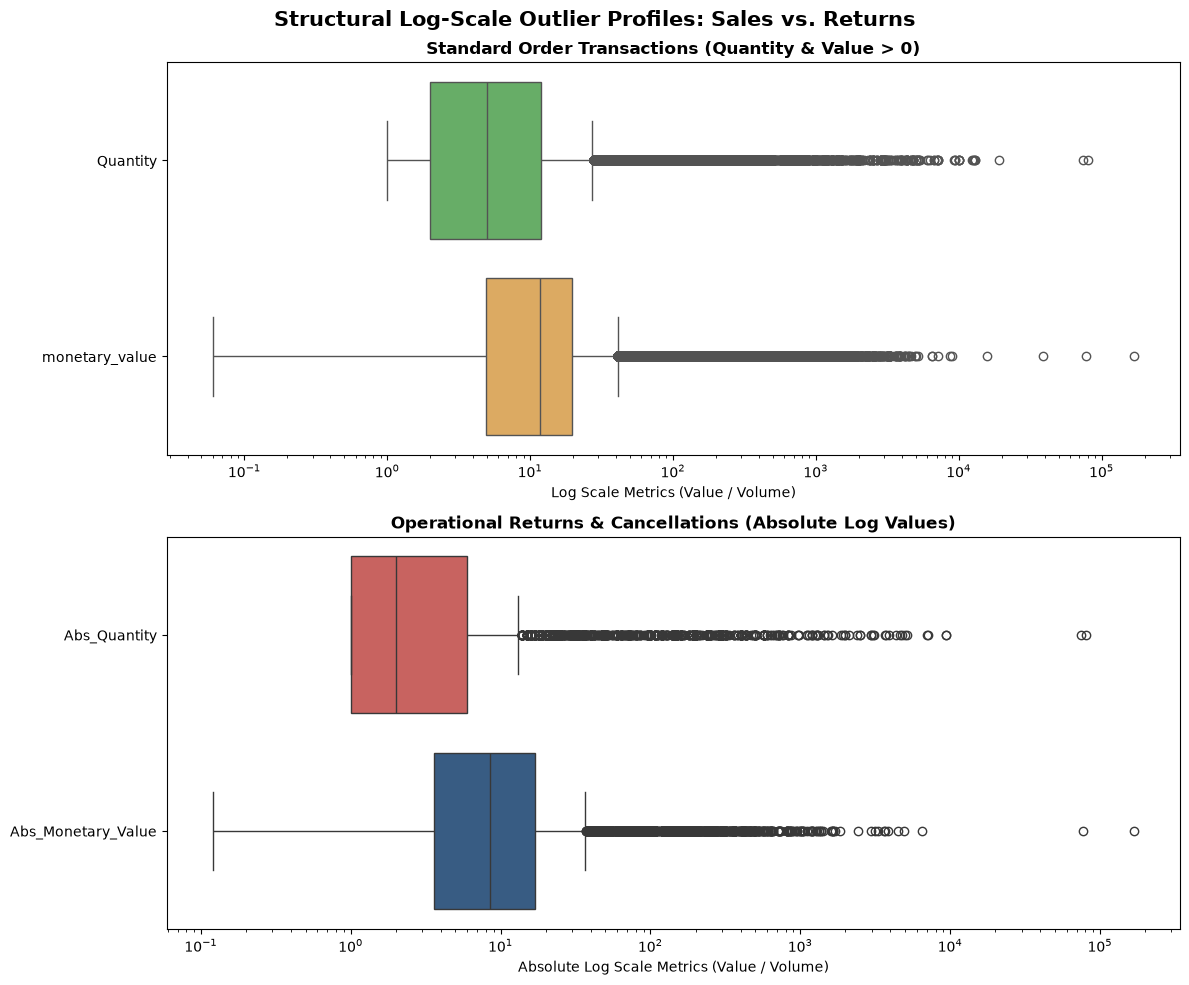

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Splitting into 2 rows and 1 column (Up and Down subplots layout)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# ----------------------------------------------------------------------
# TOP SUBPLOT (Row 0): Actual Invoices (Quantity > 0)
# ----------------------------------------------------------------------
positive_invoices = file[file['Quantity'] > 0]

# Creating a long-form DataFrame slice for easier visualization mapping
pos_melted = positive_invoices[['Quantity', 'monetary_value']].copy()
# Ensure monetary value doesn't hit 0 to prevent logarithmic infinity breaks
pos_melted = pos_melted[pos_melted['monetary_value'] > 0]

# Constructing a side-by-side or combined layout within the top panel
sns.boxplot(data=pos_melted, orient='h', ax=axes[0], palette=['#5cb85c', '#f0ad4e'])
axes[0].set_xscale('log')
axes[0].set_title('Standard Order Transactions (Quantity & Value > 0)', fontsize=12, weight='bold')
axes[0].set_xlabel('Log Scale Metrics (Value / Volume)')

# ----------------------------------------------------------------------
# BOTTOM SUBPLOT (Row 1): Return Invoices (Quantity < 0)
# ----------------------------------------------------------------------
return_invoices = file[file['Quantity'] < 0].copy()

# converting negative bounds to absolute positive numbers to protect the downstream log-scale axis formatting math.
return_invoices['Abs_Quantity'] = return_invoices['Quantity'].abs()
return_invoices['Abs_Monetary_Value'] = return_invoices['monetary_value'].abs()
return_invoices = return_invoices[return_invoices['Abs_Monetary_Value'] > 0]

sns.boxplot(
    data=return_invoices[['Abs_Quantity', 'Abs_Monetary_Value']], 
    orient='h', 
    ax=axes[1], 
    palette=['#d9534f', '#2b5c8f']
)
axes[1].set_xscale('log')
axes[1].set_title('Operational Returns & Cancellations (Absolute Log Values)', fontsize=12, weight='bold')
axes[1].set_xlabel('Absolute Log Scale Metrics (Value / Volume)')

# Final Layout adjustments
plt.suptitle('Structural Log-Scale Outlier Profiles: Sales vs. Returns', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\sangr\AppData\Local\Temp\ipykernel_42896\1555053947.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return_invoice['Abs_Quantity'] = return_invoice['Quantity'].abs()
C:\Users\sangr\AppData\Local\Temp\ipykernel_42896\1555053947.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return_invoice['Abs_Monetary_Value'] = return_invoice['monetary_value'].abs()


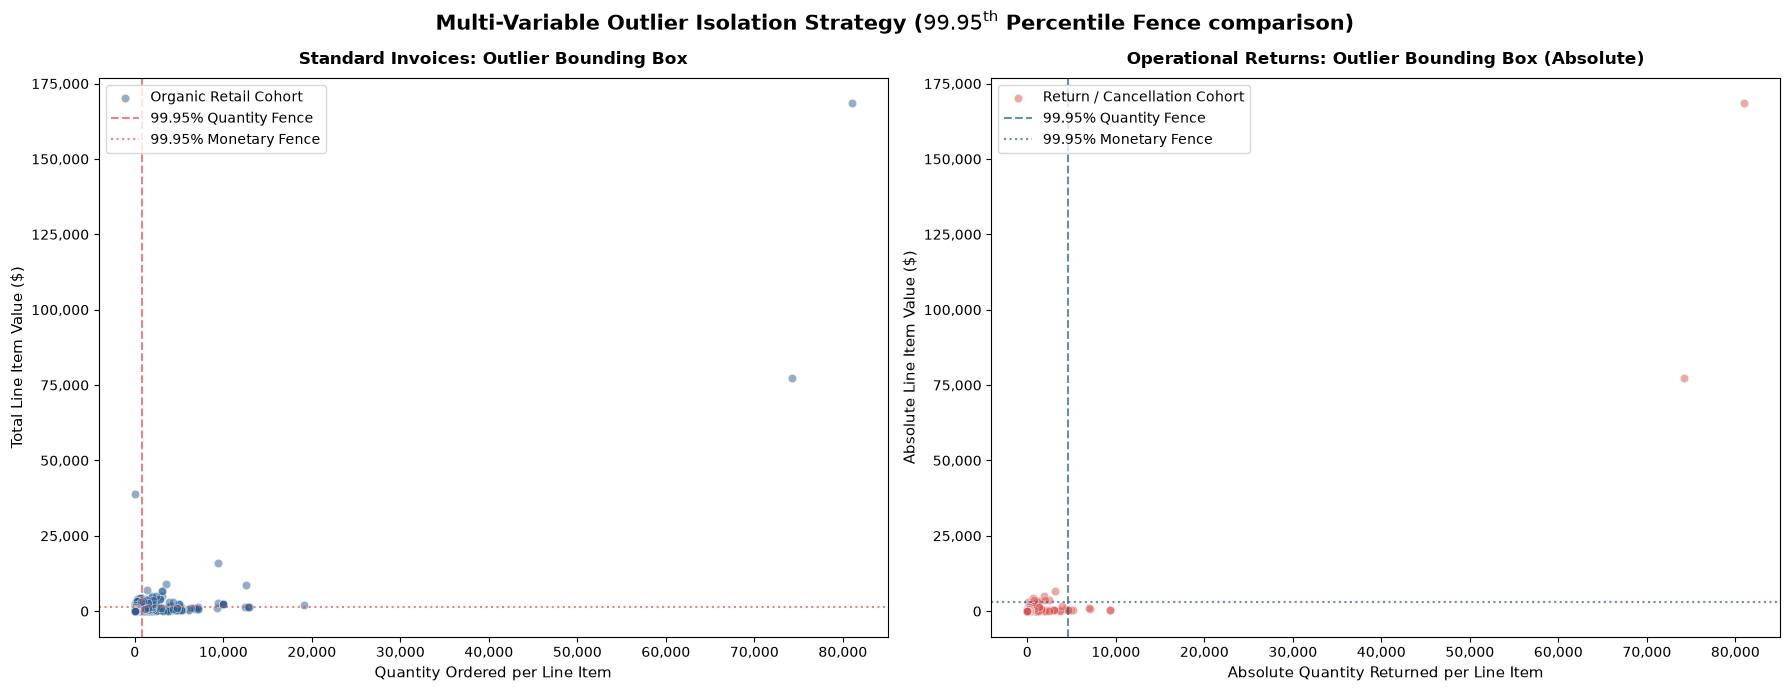

In [17]:
# Create a 1-row, 2-column subplot grid matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))


# LEFT PLOT (axes[0]): Organic Retail Invoices (Quantity > 0)
invoice = file[file['Quantity'] > 0]
sns.scatterplot(
    data=invoice, 
    x='Quantity', 
    y='monetary_value', 
    alpha=0.5, 
    color='#2b5c8f', 
    ax=axes[0],
    label='Organic Retail Cohort'
)

# Compute and draw 99.95% thresholds for invoices
inv_qty_fence = invoice["Quantity"].quantile(0.9995)
inv_mon_fence = invoice["monetary_value"].quantile(0.9995)

axes[0].axvline(x=inv_qty_fence, color='#d9534f', linestyle='--', alpha=0.7, label='99.95% Quantity Fence')
axes[0].axhline(y=inv_mon_fence, color='#d9534f', linestyle=':', alpha=0.7, label='99.95% Monetary Fence')

axes[0].set_title('Standard Invoices: Outlier Bounding Box', fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel('Quantity Ordered per Line Item', fontsize=11)
axes[0].set_ylabel('Total Line Item Value ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].legend(loc='upper left', frameon=True)

# Right Plot: Returns & Cancellations (Absolute Values)
return_invoice = file[file['Quantity'] < 0]
return_invoice['Abs_Quantity'] = return_invoice['Quantity'].abs()
return_invoice['Abs_Monetary_Value'] = return_invoice['monetary_value'].abs()
sns.scatterplot(
    data=return_invoice, 
    x='Abs_Quantity', 
    y='Abs_Monetary_Value', 
    alpha=0.5, 
    color='#d9534f', 
    ax=axes[1],
    label='Return / Cancellation Cohort'
)

# Compute and draw 99.95% thresholds for returns
ret_qty_fence = return_invoice["Abs_Quantity"].quantile(0.9995)
ret_mon_fence = return_invoice["Abs_Monetary_Value"].quantile(0.9995)

axes[1].axvline(x=ret_qty_fence, color='#2b5c8f', linestyle='--', alpha=0.7, label='99.95% Quantity Fence')
axes[1].axhline(y=ret_mon_fence, color='#2b5c8f', linestyle=':', alpha=0.7, label='99.95% Monetary Fence')

axes[1].set_title('Operational Returns: Outlier Bounding Box (Absolute)', fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel('Absolute Quantity Returned per Line Item', fontsize=11)
axes[1].set_ylabel('Absolute Line Item Value ($)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].legend(loc='upper left', frameon=True)

# Global layout tuning
plt.suptitle('Multi-Variable Outlier Isolation Strategy ($99.95^{\\text{th}}$ Percentile Fence comparison)', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()

# Save the plot asset safely to directory storage
plt.savefig('outlier_isolation_comparison.png', dpi=300, bbox_inches='tight')
# Note: If running live inside a Jupyter Notebook cell, you can append plt.show() here.

We surgically removed the top two extreme data points for Price and Quantity to protect our distance-based modeling from extreme scaling distortion. This step eliminates single-point system anomalies while fully preserving the legitimate, heavy-tailed distribution of our enterprise wholesale clients
points where price higher than 25000 and quantity higher than 50000.

In [18]:
# ---> PLACE THE TOP 2 EXTREME DROP CODE HERE <---
top_2_price_idx = file[file['Price']>25000].index
top_2_qty_idx = file[file['Quantity']>50000].index

#return invoices:
ret_top_2_price_idx = file[file['Price']<-25000].index
ret_top_2_qty_idx = file[file['Quantity']<-50000].index

file = file.drop(index=top_2_price_idx.union(top_2_qty_idx))
file = file.drop(index=ret_top_2_price_idx.union(ret_top_2_qty_idx)).reset_index(drop=True)

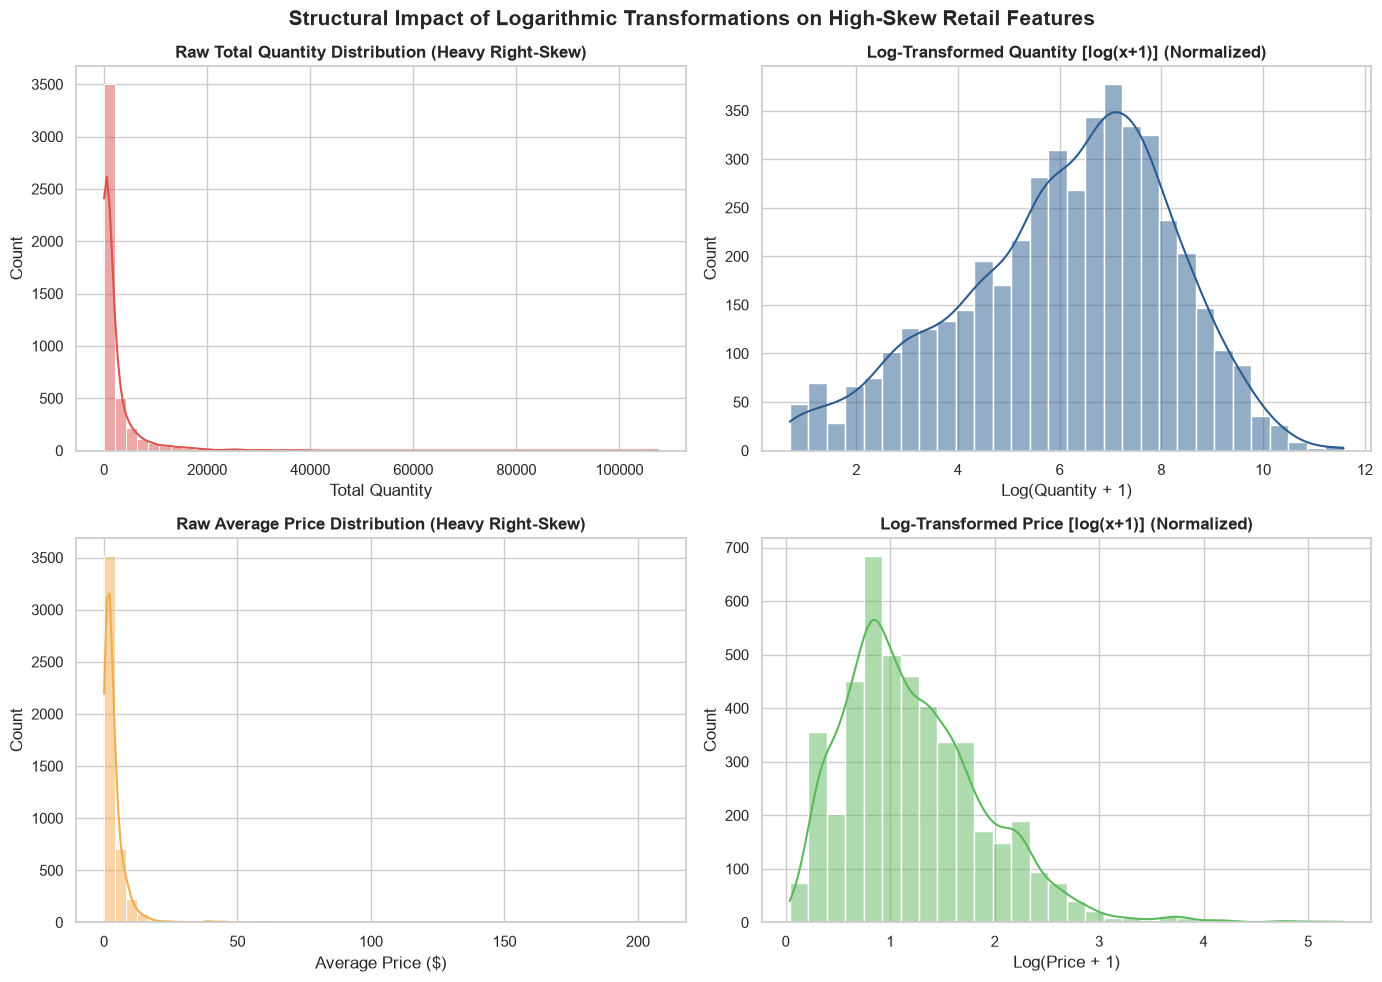

In [19]:
# 1. Aggregate at the Product level using Total Quantity and Average Unit Price
product_profiles = file.groupby('StockCode').agg(
    TotalQuantity=('Quantity', 'sum'),
    AvgPrice=('Price', 'mean'),  # Directly isolating item pricing behavior
    TotalMonetary=('monetary_value', 'sum'),
    TransactionCount=('Invoice', 'count')
).reset_index()

product_profiles = product_profiles[
    (product_profiles['TotalQuantity'] > 0) & 
    (product_profiles['AvgPrice'] > 0)
].copy()

# 2. Log-Transform both features to control the massive right-skew
product_profiles['log_qty'] = np.log1p(product_profiles['TotalQuantity'])
product_profiles['log_price'] = np.log1p(product_profiles['AvgPrice'])

# Configure clean aesthetic layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------------------------------
# VARIABLE 1: QUANTITY
# --------------------------------------------------------
# Raw Quantity Distribution (Truncated slightly to show the bulk wall)
sns.histplot(data=product_profiles, x='TotalQuantity', kde=True, ax=axes[0, 0], color='#d9534f', bins=50)
axes[0, 0].set_title('Raw Total Quantity Distribution (Heavy Right-Skew)', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Total Quantity')

# Log-Transformed Quantity Distribution
sns.histplot(data=product_profiles, x='log_qty', kde=True, ax=axes[0, 1], color='#2b5c8f', bins=30)
axes[0, 1].set_title('Log-Transformed Quantity [log(x+1)] (Normalized)', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Log(Quantity + 1)')

# --------------------------------------------------------
# VARIABLE 2: AVERAGE PRICE
# --------------------------------------------------------
# Raw Price Distribution
sns.histplot(data=product_profiles, x='AvgPrice', kde=True, ax=axes[1, 0], color='#f0ad4e', bins=50)
axes[1, 0].set_title('Raw Average Price Distribution (Heavy Right-Skew)', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Average Price ($)')

# Log-Transformed Price Distribution
sns.histplot(data=product_profiles, x='log_price', kde=True, ax=axes[1, 1], color='#5cb85c', bins=30)
axes[1, 1].set_title('Log-Transformed Price [log(x+1)] (Normalized)', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Log(Price + 1)')

plt.suptitle('Structural Impact of Logarithmic Transformations on High-Skew Retail Features', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Statistical Takeaway: Log-Normal Transformation Justification
- Both TotalQuantity and AvgPrice are heavily skewed to the right. The vast majority of our regular retail items are packed tightly together near zero, while a small handful of massive B2B wholesale orders stretch out into a long, sparse tail.

- The Mathematical Issue: Distance-based algorithms like K-Means calculate the straight-line distance between points. If we leave the data unscaled, those massive wholesale numbers will completely dominate the math. The algorithm will get overwhelmed by the scale difference and force 99% of our standard retail products into a single, massive cluster.

- The Fix [log(x+1)]: Applying a natural log transformation pulls those extreme wholesale values closer to the rest of the data and normalizes the distribution shape. This evens out the playing field, allowing our clustering algorithm to draw clean, mathematically balanced boundaries between our different product categories.

## The Problem with Standard Outlier Removal
When we first ran typical cleanup methods—like cutting data off at the 99.99th percentile or using the Interquartile Range ($3 \times \text{IQR}$)—the results weren't right. These methods blindly dropped our biggest data points. A closer look revealed that these huge orders weren't mistakes,  or outliers. They represented real bulk wholesale and B2B buyers. Dropping them meant loosing our highest-revenue customers and losing the data we need to model corporate churn.

## The Solution: 
We used $K$-Means clustering on a log-transformed scale to group our inventory into distinct business categories: 
- Everyday Retail Stock: Low-to-medium volume items.
- High-Ticket Luxury Tier: Low-velocity items that carry massive price tags.
- Bulk Wholesale Drivers: High-volume items moving in industrial quantities.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Aggregate at the Product level using Total Quantity and Average Unit Price
product_profiles = file.groupby('StockCode').agg(
    TotalQuantity=('Quantity', 'sum'),
    AvgPrice=('Price', 'mean'),  # Directly isolating item pricing behavior
    TotalMonetary=('monetary_value', 'sum'),
    TransactionCount=('Invoice', 'count')
).reset_index()

product_profiles = product_profiles[
    (product_profiles['TotalQuantity'] > 0) & 
    (product_profiles['AvgPrice'] > 0)
].copy()

# 2. Log-Transform both features to control the massive right-skew
product_profiles['log_qty'] = np.log1p(product_profiles['TotalQuantity'])
product_profiles['log_price'] = np.log1p(product_profiles['AvgPrice'])



# 3. Scale the features for K-Means distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(product_profiles[['log_qty', 'log_price']])

# 4. Custom Parameter Grid Search (Optimizing via Silhouette Score)
param_grid = {
    'n_clusters': [3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 500,1000]
}

best_score = -1
best_params = {}
best_model = None

print("--- Running Custom Unsupervised Hyperparameter Grid Search ---")
for n_clusters in param_grid['n_clusters']:
    for init in param_grid['init']:
        for max_iter in param_grid['max_iter']:
            
            # Instantiate and fit candidate configurations
            km = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42, n_init=10)
            labels = km.fit_predict(X_scaled)
            
            # Calculate Silhouette Score (measures cluster separation and cohesion)
            score = silhouette_score(X_scaled, labels)
            
            if score > best_score:
                best_score = score
                best_params = {'n_clusters': n_clusters, 'init': init, 'max_iter': max_iter}
                best_model = km

print(f"\nOptimal Parameters Found: {best_params}")
print(f"Best Silhouette Score: {best_score:.4f}")

# 5. Assign the optimal cluster tags back to your items
product_profiles['Cluster'] = best_model.labels_

# 6. Profile the new Quantity vs. Price Categories
cluster_summary = product_profiles.groupby('Cluster').agg(
    ProductCount=('StockCode', 'count'),
    MeanQty=('TotalQuantity', 'mean'),
    MaxQty=('TotalQuantity', 'max'),
    MeanPrice=('AvgPrice', 'mean'),
    MaxPrice=('AvgPrice', 'max')
).reset_index()

print("\n--- Optimized Cluster Profiles Summary ---")
print(cluster_summary)

--- Running Custom Unsupervised Hyperparameter Grid Search ---

Optimal Parameters Found: {'n_clusters': 3, 'init': 'k-means++', 'max_iter': 300}
Best Silhouette Score: 0.3897

--- Optimized Cluster Profiles Summary ---
   Cluster  ProductCount      MeanQty  MaxQty  MeanPrice    MaxPrice
0        0          2369  4025.918531  107489   1.567289    6.938944
1        1          1095   522.947945   23446   9.845817  207.520408
2        2          1133   103.403354     397   2.186151    6.750000


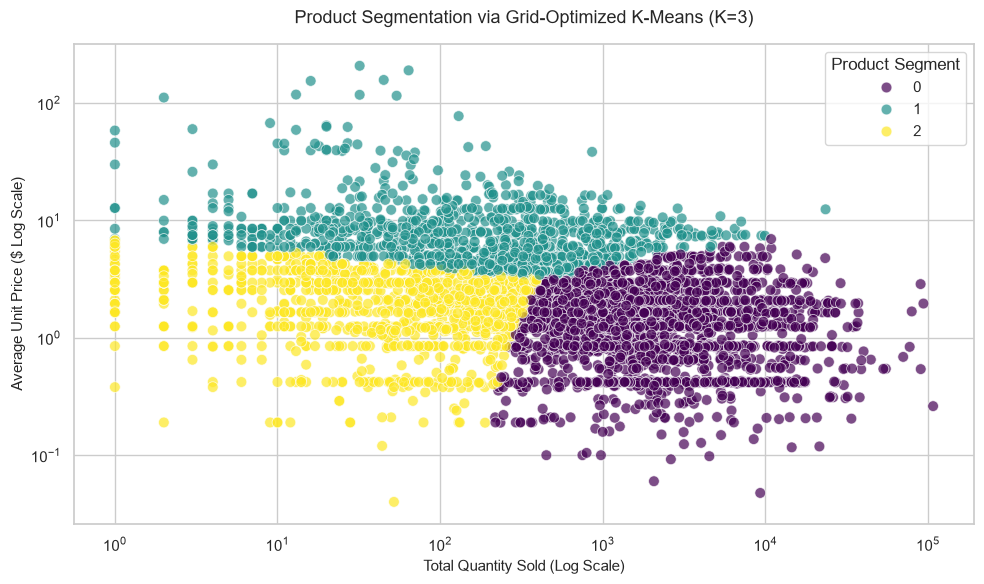

In [21]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotting on a log-log scale for clear structural layout visibility
sns.scatterplot(
    data=product_profiles, 
    x='TotalQuantity', 
    y='AvgPrice', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.7, 
    s=60
)

plt.xscale('log')
plt.yscale('log')
plt.title(f"Product Segmentation via Grid-Optimized K-Means (K={best_params['n_clusters']})", fontsize=13, pad=15)
plt.xlabel('Total Quantity Sold (Log Scale)', fontsize=11)
plt.ylabel('Average Unit Price ($ Log Scale)', fontsize=11)
plt.legend(title='Product Segment', loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
import os
import joblib
joblib.dump(best_model, os.path.join("models", "product_kmeans.joblib"))
print("Saved KMeans model artifact to 'models/product_kmeans.joblib'")

# 6. Map cluster tags and save lookup database
product_profiles['Cluster'] = best_model.labels_
lookup_table = product_profiles[['StockCode', 'Cluster']]
lookup_table.to_csv("data/processed/product_cluster_lookup.csv", index=False)
print("Saved lookup map to 'data/processed/product_cluster_lookup.csv'")

Saved KMeans model artifact to 'models/product_kmeans.joblib'
Saved lookup map to 'data/processed/product_cluster_lookup.csv'


In [7]:
import pandas as pd
import numpy as np
file=pd.read_csv(r"data\processed\cleaned_transactions.csv")
file.head()
file['InvoiceDate'] = pd.to_datetime(file['InvoiceDate'])


positive_sales = file[file['Quantity'] > 0].copy()

# 3. Identify unique clusters present in the dataset (excluding unclassified -1 if necessary)
clusters = sorted([c for c in positive_sales['Cluster'].unique() if c != -1])

print("====================================================================")
print("     STRATIFIED PURCHASE INTERVAL ANALYSIS BY PRODUCT CLUSTER       ")
print("====================================================================\n")

cluster_stats = {}

# 4. Iterate through each K-Means cluster to extract independent behavioral metrics
for cluster_id in clusters:
    # Isolate sales belonging strictly to the current product cluster segment
    cluster_sales = positive_sales[positive_sales['Cluster'] == cluster_id]
    
    # Filter for repeat buyers within this specific cluster footprint (>= 2 unique invoices)
    repeat_buyers = cluster_sales.groupby('Customer ID').filter(lambda x: x['Invoice'].nunique() >= 2)
    
    purchase_intervals = []
    
    # Calculate the chronological delta between consecutive purchases per customer
    for cid, group in repeat_buyers.groupby('Customer ID'):
        sorted_dates = group['InvoiceDate'].sort_values().unique()
        intervals = np.diff(sorted_dates) / np.timedelta64(1, 'D')
        purchase_intervals.extend(intervals)
        
    # Convert to standard Series for statistical profiling
    intervals_series = pd.Series(purchase_intervals)
    
    if not intervals_series.empty:
        p50 = intervals_series.median()
        p90 = intervals_series.quantile(0.90)
        p95 = intervals_series.quantile(0.95)
        total_intervals_tracked = len(intervals_series)
        unique_customers = repeat_buyers['Customer ID'].nunique()
        
        # Store for downstream reporting or tabular extraction
        cluster_stats[cluster_id] = {'P50': p50, 'P90': p90, 'P95': p95}
        
        print(f"--- [Cluster {cluster_id}] Behavioral Segment Profile ---")
        print(f"  * Sample Size      : {unique_customers} repeat customers ({total_intervals_tracked} order cycles)")
        print(f"  * Median Interval  : {p50:.1f} days (Typical baseline cycle)")
        print(f"  * 90th Percentile  : {p90:.1f} days")
        print(f"  * 95th Percentile  : {p95:.1f} days (Statistical Outlier Threshold)\n")
    else:
        print(f"--- [Cluster {cluster_id}] Behavioral Segment Profile ---")
        print("  * Insufficient repeat purchase frequency records inside this cluster slice.\n")

print("====================================================================")

C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\2792575221.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  file=pd.read_csv(r"data\processed\cleaned_transactions.csv")


     STRATIFIED PURCHASE INTERVAL ANALYSIS BY PRODUCT CLUSTER       

--- [Cluster 0] Behavioral Segment Profile ---
  * Sample Size      : 4327 repeat customers (29473 order cycles)
  * Median Interval  : 26.9 days (Typical baseline cycle)
  * 90th Percentile  : 139.1 days
  * 95th Percentile  : 210.0 days (Statistical Outlier Threshold)

--- [Cluster 1] Behavioral Segment Profile ---
  * Sample Size      : 3775 repeat customers (21700 order cycles)
  * Median Interval  : 32.0 days (Typical baseline cycle)
  * 90th Percentile  : 157.9 days
  * 95th Percentile  : 235.0 days (Statistical Outlier Threshold)

--- [Cluster 2] Behavioral Segment Profile ---
  * Sample Size      : 1632 repeat customers (5471 order cycles)
  * Median Interval  : 48.9 days (Typical baseline cycle)
  * 90th Percentile  : 268.8 days
  * 95th Percentile  : 364.0 days (Statistical Outlier Threshold)



# EDA on RFM Metrics

In [12]:
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

DATASET_PATH = "data/processed/customer_analytical_dataset.csv"
if not os.path.exists(DATASET_PATH):
    print(f"⚠️ Error: Please generate the analytical dataset first at: {DATASET_PATH}")
else:
    df = pd.read_csv(DATASET_PATH)
    print(f"✅ Dataset loaded successfully. Shape: {df.shape}")

✅ Dataset loaded successfully. Shape: (4590, 25)


--- Churn Class Proportions ---
Active Base (0): 2098 (45.71%)
Churned Base (1): 2492 (54.29%)


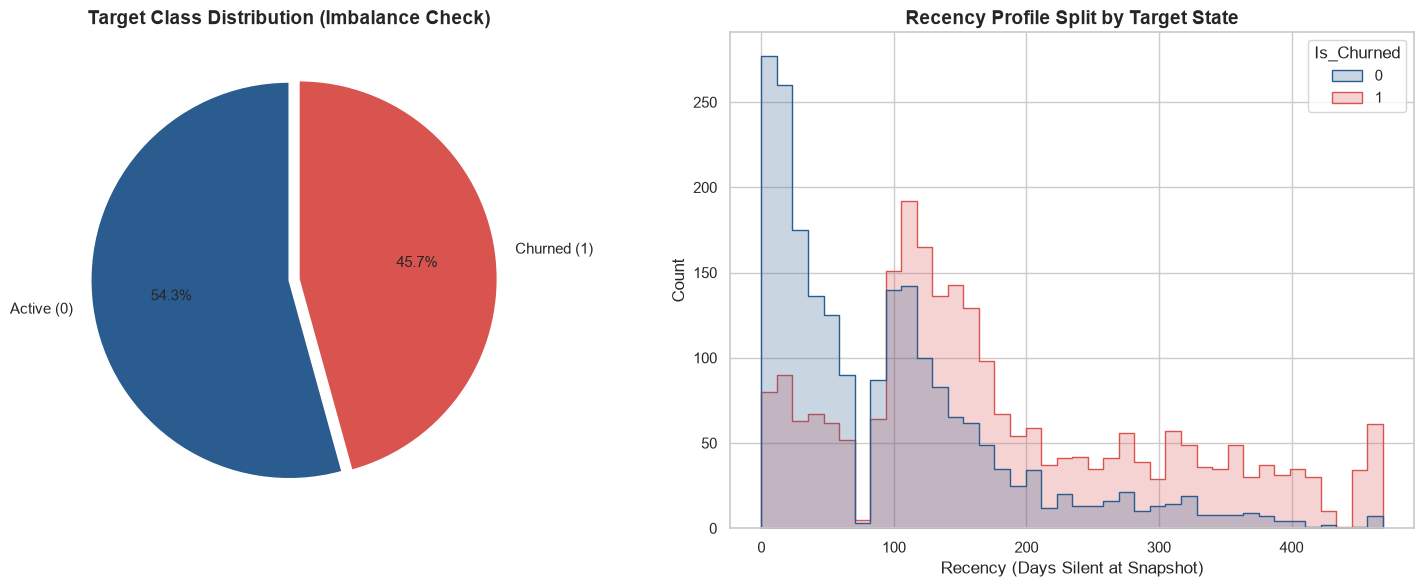

In [13]:
print("--- Churn Class Proportions ---")
churn_counts = df['Is_Churned'].value_counts()
churn_pcts = df['Is_Churned'].value_counts(normalize=True) * 100
print(f"Active Base (0): {churn_counts[0]} ({churn_pcts[0]:.2f}%)")
print(f"Churned Base (1): {churn_counts[1]} ({churn_pcts[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].pie(churn_counts, labels=['Active (0)', 'Churned (1)'], autopct='%1.1f%%', 
            startangle=90, colors=['#2b5c8f', '#d9534f'], explode=(0, 0.05))
axes[0].set_title('Target Class Distribution (Imbalance Check)', weight='bold')

sns.histplot(data=df, x='Recency', hue='Is_Churned', ax=axes[1], 
             palette=['#2b5c8f', '#d9534f'], element='step', stat='count', common_norm=False, bins=40)
axes[1].set_title('Recency Profile Split by Target State', weight='bold')
axes[1].set_xlabel('Recency (Days Silent at Snapshot)')

plt.tight_layout()
plt.show()

--- Median Lifecycle Metrics Across Classes ---
            Recency  Frequency  LifetimeSpend     AOV  CustomerTenureDays
Is_Churned                                                               
0              68.0        4.0        1399.68  312.19               361.0
1             151.0        2.0         417.84  236.92               299.0


C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3370541804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Churned', y='Frequency', ax=axes[0, 0], palette=['#2b5c8f', '#d9534f'], showfliers=False)
C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3370541804.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(['Active (0)', 'Churned (1)'])
C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3370541804.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Churned', y='LifetimeSpend', ax=axes[0, 1], palette=['#2b5c8

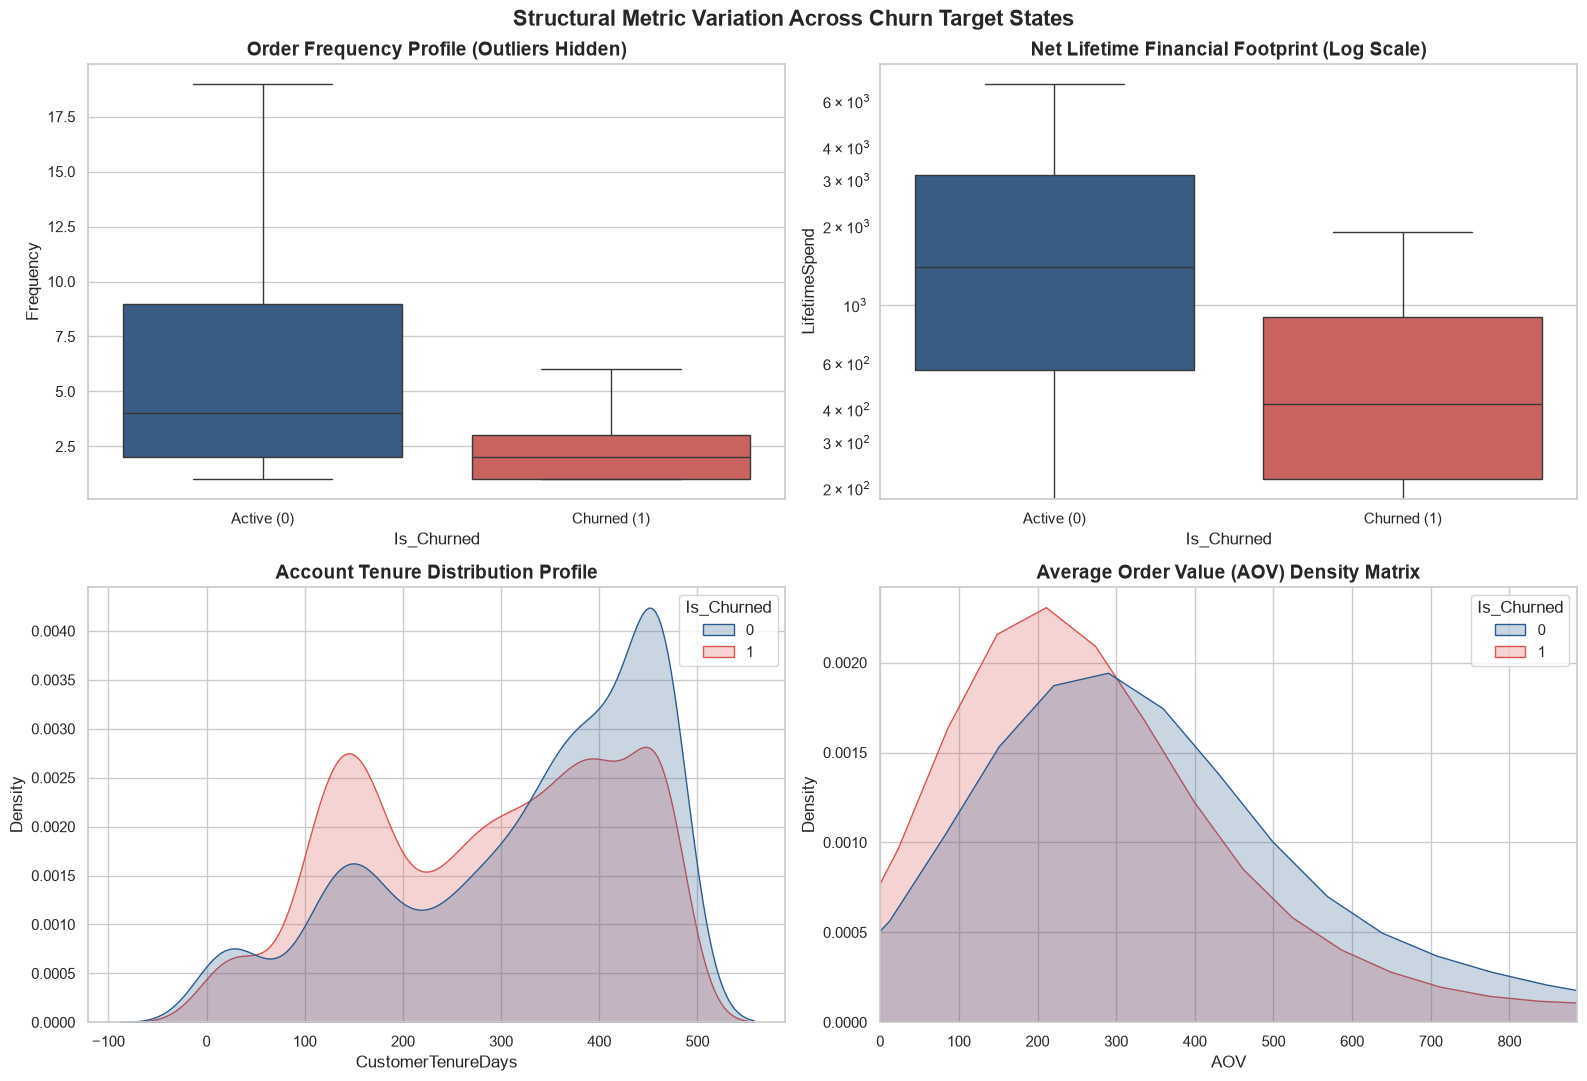

In [14]:
print("--- Median Lifecycle Metrics Across Classes ---")
print(df.groupby('Is_Churned')[['Recency', 'Frequency', 'LifetimeSpend', 'AOV', 'CustomerTenureDays']].median().round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.boxplot(data=df, x='Is_Churned', y='Frequency', ax=axes[0, 0], palette=['#2b5c8f', '#d9534f'], showfliers=False)
axes[0, 0].set_title('Order Frequency Profile (Outliers Hidden)', weight='bold')
axes[0, 0].set_xticklabels(['Active (0)', 'Churned (1)'])

sns.boxplot(data=df, x='Is_Churned', y='LifetimeSpend', ax=axes[0, 1], palette=['#2b5c8f', '#d9534f'], showfliers=False)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Net Lifetime Financial Footprint (Log Scale)', weight='bold')
axes[0, 1].set_xticklabels(['Active (0)', 'Churned (1)'])

sns.kdeplot(data=df, x='CustomerTenureDays', hue='Is_Churned', ax=axes[1, 0], fill=True, palette=['#2b5c8f', '#d9534f'], common_norm=False)
axes[1, 0].set_title('Account Tenure Distribution Profile', weight='bold')

sns.kdeplot(data=df, x='AOV', hue='Is_Churned', ax=axes[1, 1], fill=True, palette=['#2b5c8f', '#d9534f'], common_norm=False)
axes[1, 1].set_xlim(0, df['AOV'].quantile(0.95))
axes[1, 1].set_title('Average Order Value (AOV) Density Matrix', weight='bold')

plt.suptitle('Structural Metric Variation Across Churn Target States', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3263711104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Churned', y='Cluster_Median_Delta', ax=axes[0], palette=['#2b5c8f', '#d9534f'], showfliers=False)
C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3263711104.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Churned', y='Financial_Momentum', ax=axes[1], palette=['#2b5c8f', '#d9534f'], showfliers=False)
C:\Users\sangr\AppData\Local\Temp\ipykernel_50608\3263711104.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

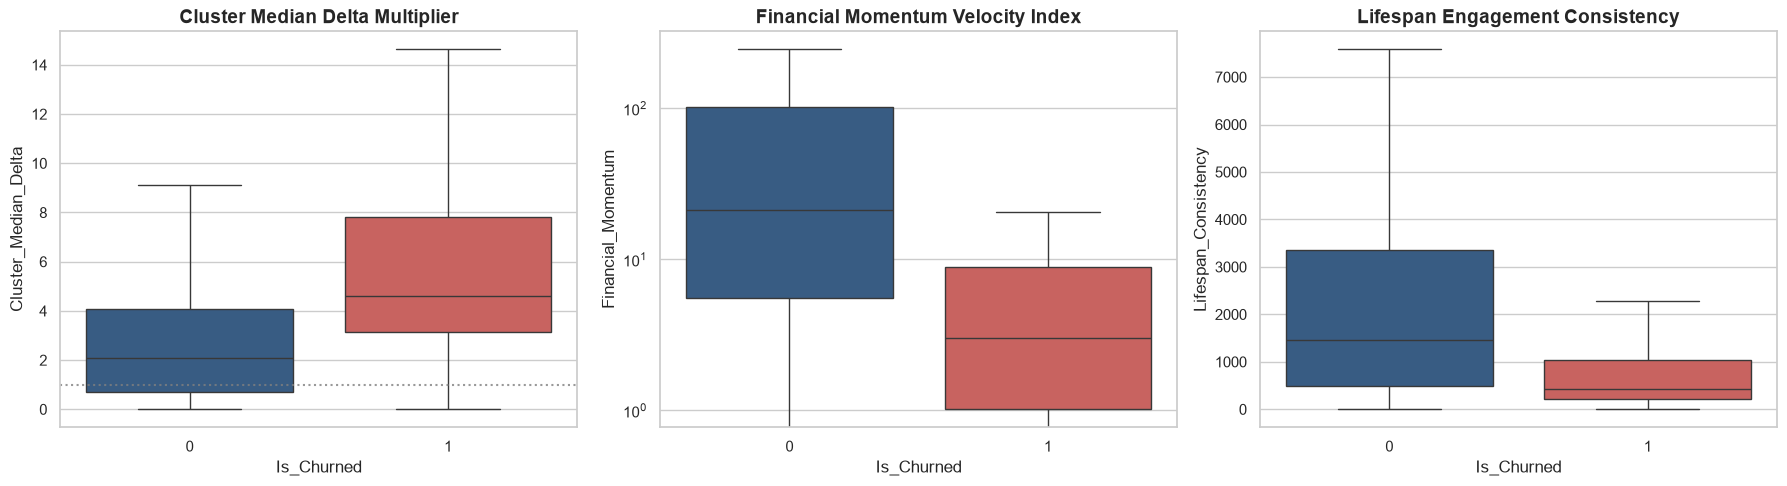

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Is_Churned', y='Cluster_Median_Delta', ax=axes[0], palette=['#2b5c8f', '#d9534f'], showfliers=False)
axes[0].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)
axes[0].set_title('Cluster Median Delta Multiplier', weight='bold')

sns.boxplot(data=df, x='Is_Churned', y='Financial_Momentum', ax=axes[1], palette=['#2b5c8f', '#d9534f'], showfliers=False)
axes[1].set_yscale('log')
axes[1].set_title('Financial Momentum Velocity Index', weight='bold')

sns.boxplot(data=df, x='Is_Churned', y='Lifespan_Consistency', ax=axes[2], palette=['#2b5c8f', '#d9534f'], showfliers=False)
axes[2].set_title('Lifespan Engagement Consistency', weight='bold')

plt.tight_layout()
plt.show()

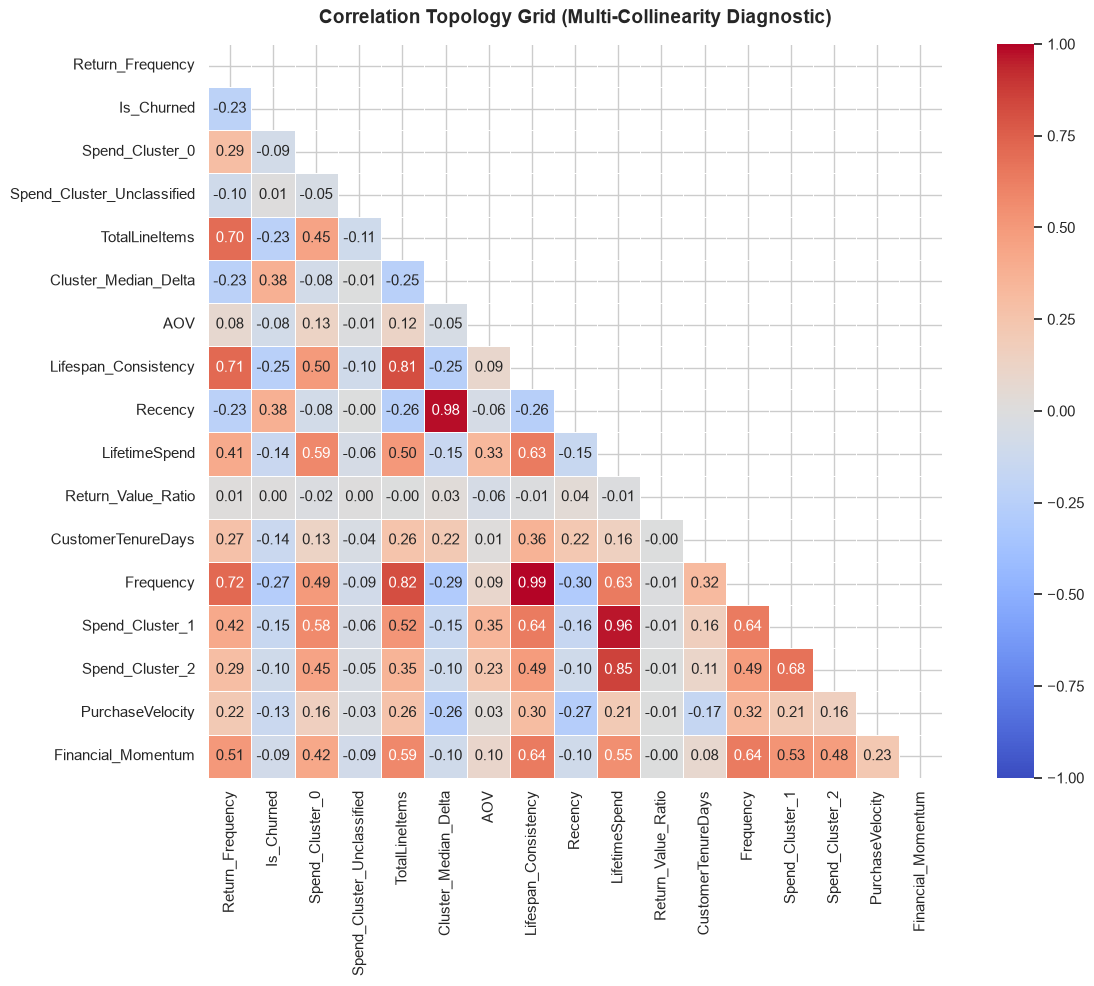

In [16]:
cols_to_correlate = [
    'Recency', 'Frequency', 'LifetimeSpend', 'TotalLineItems', 'AOV', 
    'CustomerTenureDays', 'PurchaseVelocity', 'Return_Frequency', 
    'Return_Value_Ratio', 'Cluster_Median_Delta', 'Financial_Momentum', 
    'Lifespan_Consistency', 'Is_Churned'
]
cluster_cols = [c for c in df.columns if 'Spend_Cluster_' in c]
cols_to_correlate.extend(cluster_cols)
cols_to_correlate = [c for c in list(set(cols_to_correlate)) if c in df.columns]

corr_matrix = df[cols_to_correlate].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Topology Grid (Multi-Collinearity Diagnostic)', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()